<a href="https://colab.research.google.com/github/yehuda-yu/Data_Science_Projects/blob/main/Gantt_chart_script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## How to create gantt chart for schedule pipeline?
based on this [link](https://towardsdatascience.com/gantt-charts-with-pythons-matplotlib-395b7af72d72).

#### **By**: Yehuda Yungstein

### 1. Import the packages

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import numpy as np
import datetime as dt
# Set the font to Times new roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [ ]:
# import the data:
df = pd.read_excel('/content/PhD_Gantt_chart_data.xlsx')

# Set the time columns as datetime:
df['Start'] = pd.to_datetime(df['Start'],dayfirst=True)
df['End'] = pd.to_datetime(df['End'],dayfirst=True)
df

,Task,Name,Phase,Start,End,Completion
0,Paper 3,NaN,Ph.D.,2025-07-01,2025-10-01,0.0
1,Task 4.2,Using the Models for Detecting Spatial Anomali...,NaN,2025-04-01,2025-07-01,0.0
2,Task 4.1,Design an image-based monitoring model based o...,Ph.D.,2024-10-01,2025-04-01,0.0
3,Task 3.2,Develop an ML-based planning model based on LI...,Ph.D.,2024-04-01,2024-10-01,1.0
4,Paper 2,NaN,Ph.D.,2023-11-01,2024-04-01,0.5
5,Task 3.1,Develop an ML Project App System using the Str...,Ph.D.,2023-06-01,2023-11-01,1.0
6,Paper 1,"co2 reduction, and energy-saving benefits of a...",M.Sc.,2022-07-01,2022-10-01,1.0
7,Task 2.2,CO2 indoor enrichment experiment,M.Sc.,2022-07-30,2022-10-10,1.0
8,Task 2.1,Estimate impacts on Indoor Temperature and RH,M.Sc.,2022-06-01,2022-09-01,1.0
9,Task 1.3,Generate general light and CO2 response curves...,M.Sc.,2022-02-01,2022-06-01,1.0


In [ ]:
# project start date
proj_start = df.Start.min()
# number of days from project start to task start
df['start_num'] = (df.Start-proj_start).dt.days
# number of days from project start to end of tasks
df['end_num'] = (df.End-proj_start).dt.days
# days between start and end of each task
df['days_start_to_end'] = df.end_num - df.start_num

In [ ]:
# create a column with the color for each kind of the task
def color(row):
    c_dict = {'Task 1.1':'#619eff', 'Task 1.2':'#619eff','Task 1.3':'#619eff',
              'Task 2.1':'#3a86ff', 'Task 2.2':'#3a86ff',
              'Paper 1':"#ffbe0b",
              'Task 3.1':'#8338ec','Task 3.2':'#8338ec',
              'Paper 2':"#ffbe0b",
              "Task 4.1":'#ff006e',"Task 4.2":'#ff006e',
              'Paper 3':"#ffbe0b"
              }
    return c_dict[row['Task']]
df['color'] = df.apply(color, axis=1)
df

,Task,Name,Phase,Start,End,Completion,start_num,end_num,days_start_to_end,color
0,Paper 3,NaN,Ph.D.,2025-07-01,2025-10-01,0.0,1350,1442,92,#ffbe0b
1,Task 4.2,Using the Models for Detecting Spatial Anomali...,NaN,2025-04-01,2025-07-01,0.0,1259,1350,91,#ff006e
2,Task 4.1,Design an image-based monitoring model based o...,Ph.D.,2024-10-01,2025-04-01,0.0,1077,1259,182,#ff006e
3,Task 3.2,Develop an ML-based planning model based on LI...,Ph.D.,2024-04-01,2024-10-01,1.0,894,1077,183,#8338ec
4,Paper 2,NaN,Ph.D.,2023-11-01,2024-04-01,0.5,742,894,152,#ffbe0b
5,Task 3.1,Develop an ML Project App System using the Str...,Ph.D.,2023-06-01,2023-11-01,1.0,589,742,153,#8338ec
6,Paper 1,"co2 reduction, and energy-saving benefits of a...",M.Sc.,2022-07-01,2022-10-01,1.0,254,346,92,#ffbe0b
7,Task 2.2,CO2 indoor enrichment experiment,M.Sc.,2022-07-30,2022-10-10,1.0,283,355,72,#3a86ff
8,Task 2.1,Estimate impacts on Indoor Temperature and RH,M.Sc.,2022-06-01,2022-09-01,1.0,224,316,92,#3a86ff
9,Task 1.3,Generate general light and CO2 response curves...,M.Sc.,2022-02-01,2022-06-01,1.0,104,224,120,#619eff


In [ ]:
# days between start and current progression of each task
df['current_num'] = (df.days_start_to_end * df.Completion)

<ipython-input-13-d2fb6f6195be>:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticks_labels[::210])


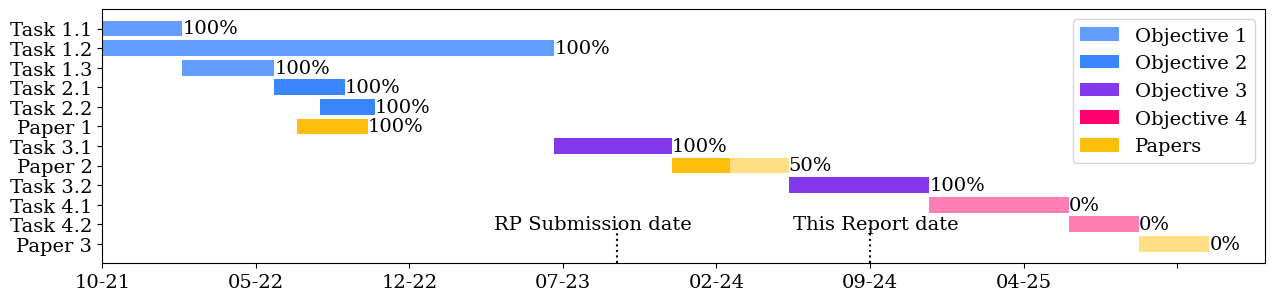

In [ ]:
from matplotlib.patches import Patch
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1, figsize=(15,3.3))
# bars
ax.barh(df.Task, df.current_num, left=df.start_num, color=df.color)
ax.barh(df.Task, df.days_start_to_end, left=df.start_num, color=df.color, alpha=0.5)

# Today line
plt.axvline(670,ymin=0, ymax=0.14,color='black',ls=":")
plt.axvline(1000,ymin=0, ymax=0.14,color='black',ls=":")
ax.text(510,1,"RP Submission date",va='center')
ax.text(900,1,"This Report date",va='center')


# texts
for idx, row in df.iterrows():
    ax.text(row.end_num+0.1, idx,
            f"{int(row.Completion*100)}%",
            va='center', alpha=1)

##### LEGENDS #####
c_dict = {'Objective 1':'#619eff',
          'Objective 2':'#3a86ff',
          'Objective 3':'#8338ec',
          'Objective 4':'#ff006e',
          'Papers':"#ffbe0b"}
legend_elements = [Patch(facecolor=c_dict[i], label=i)  for i in c_dict]
plt.legend(handles=legend_elements, fontsize=14)

##### TICKS #####
xticks_labels = pd.date_range(proj_start, end='2025-05-01').strftime("%m-%y")

ax.set_xticklabels(xticks_labels[::210])
plt.show()

In [ ]:
df

,Task,Name,Phase,Start,End,Completion,start_num,end_num,days_start_to_end,color,current_num
0,Paper 3,NaN,Ph.D.,2025-01-01,2025-05-01,0.0,1179,1299,120,#ffbe0b,0.0
1,Task 5.1,Develop a Comprehensive ML Project System usin...,Ph.D.,2024-01-01,2025-01-01,0.0,813,1179,366,#06d6a0,0.0
2,Paper 2,NaN,Ph.D.,2023-10-01,2024-01-01,0.0,721,813,92,#ffbe0b,0.0
3,Task 4.2,Utilizing Models for Spatial Mapping and Anoma...,Ph.D.,2023-09-01,2023-10-01,0.0,691,721,30,#06d6a0,0.0
4,Task 4.1,Design image-based monitoring model based on h...,Ph.D.,2023-08-01,2023-09-01,0.0,660,691,31,#06d6a0,0.0
5,Task 3.2,Develop ML-based planning model based on LI-68...,Ph.D.,2023-06-01,2023-08-01,0.5,599,660,61,#06d6a0,30.5
6,Task 3.1,Leaves samples data acquisition,M.Sc.,2021-10-10,2023-06-01,1.0,0,599,599,#06d6a0,599.0
7,Paper 1,"co2 reduction, and energy-saving benefits of a...",M.Sc.,2022-07-01,2022-10-01,1.0,264,356,92,#ffbe0b,92.0
8,Task 2.2,CO2 experiments,M.Sc.,2022-07-30,2022-10-10,1.0,293,365,72,#8338ec,72.0
9,Task 2.1,Temperature and RH,M.Sc.,2022-06-01,2022-09-01,1.0,234,326,92,#8338ec,92.0


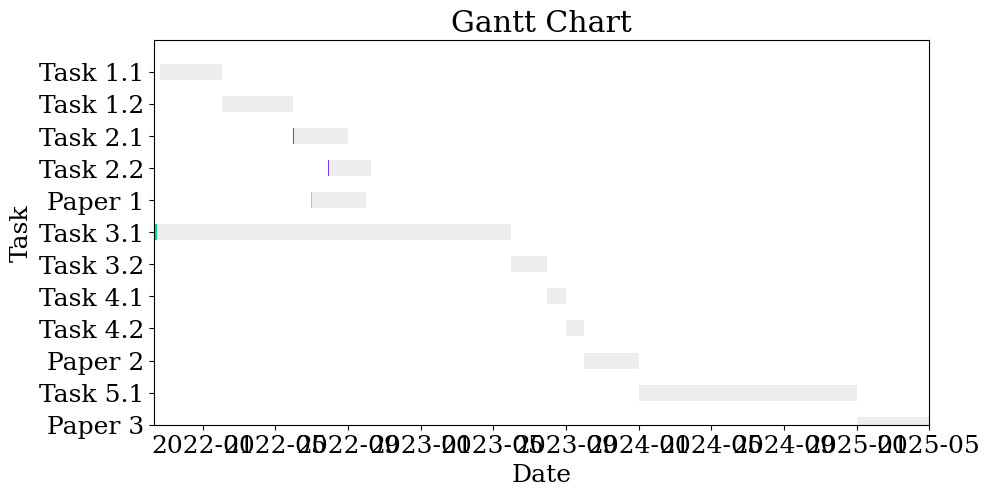

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# df = pd.read_csv('your_file.csv')

# Convert the date columns to datetime objects
df['Start'] = pd.to_datetime(df['Start'])
df['End'] = pd.to_datetime(df['End'])

# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10, 5))

# Set the x-axis limits
ax.set_xlim([df['Start'].min(), df['End'].max()])

# Set the y-axis limits
ax.set_ylim([0, len(df)])

# Set the y-axis labels
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['Task'])

# Plot the bars for each task
for i in range(len(df)):
    start = df['Start'][i]
    end = df['End'][i]
    color = df['color'][i]
    alpha = df['Completion'][i]
    ax.barh(i, end - start, left=start, height=0.5, color='lightgray', alpha=0.4)
    ax.barh(i, (end - start) * alpha / 100, left=start, height=0.5, color=color, alpha=1)

# Set the title and axis labels
ax.set_title('Gantt Chart')
ax.set_xlabel('Date')
ax.set_ylabel('Task')

# Save the chart as a PNG file
plt.savefig('chart.png')

plt.show()


In [ ]:
df

,Task,Name,Phase,Start,End,Completion,start_num,end_num,days_start_to_end,color,current_num
0,Paper 3,NaN,Ph.D.,2025-01-01,2025-05-01,0.0,1179,1299,120,#ffbe0b,0.0
1,Task 5.1,Develop a Comprehensive ML Project System usin...,Ph.D.,2024-01-01,2025-01-01,0.0,813,1179,366,#06d6a0,0.0
2,Paper 2,NaN,Ph.D.,2023-10-01,2024-01-01,0.0,721,813,92,#ffbe0b,0.0
3,Task 4.2,Utilizing Models for Spatial Mapping and Anoma...,Ph.D.,2023-09-01,2023-10-01,0.0,691,721,30,#06d6a0,0.0
4,Task 4.1,Design image-based monitoring model based on h...,Ph.D.,2023-08-01,2023-09-01,0.0,660,691,31,#06d6a0,0.0
5,Task 3.2,Develop ML-based planning model based on LI-68...,Ph.D.,2023-06-01,2023-08-01,0.5,599,660,61,#06d6a0,30.5
6,Task 3.1,Leaves samples data acquisition,M.Sc.,2021-10-10,2023-06-01,1.0,0,599,599,#06d6a0,599.0
7,Paper 1,"co2 reduction, and energy-saving benefits of a...",M.Sc.,2022-07-01,2022-10-01,1.0,264,356,92,#ffbe0b,92.0
8,Task 2.2,CO2 experiments,M.Sc.,2022-07-30,2022-10-10,1.0,293,365,72,#8338ec,72.0
9,Task 2.1,Temperature and RH,M.Sc.,2022-06-01,2022-09-01,1.0,234,326,92,#8338ec,92.0


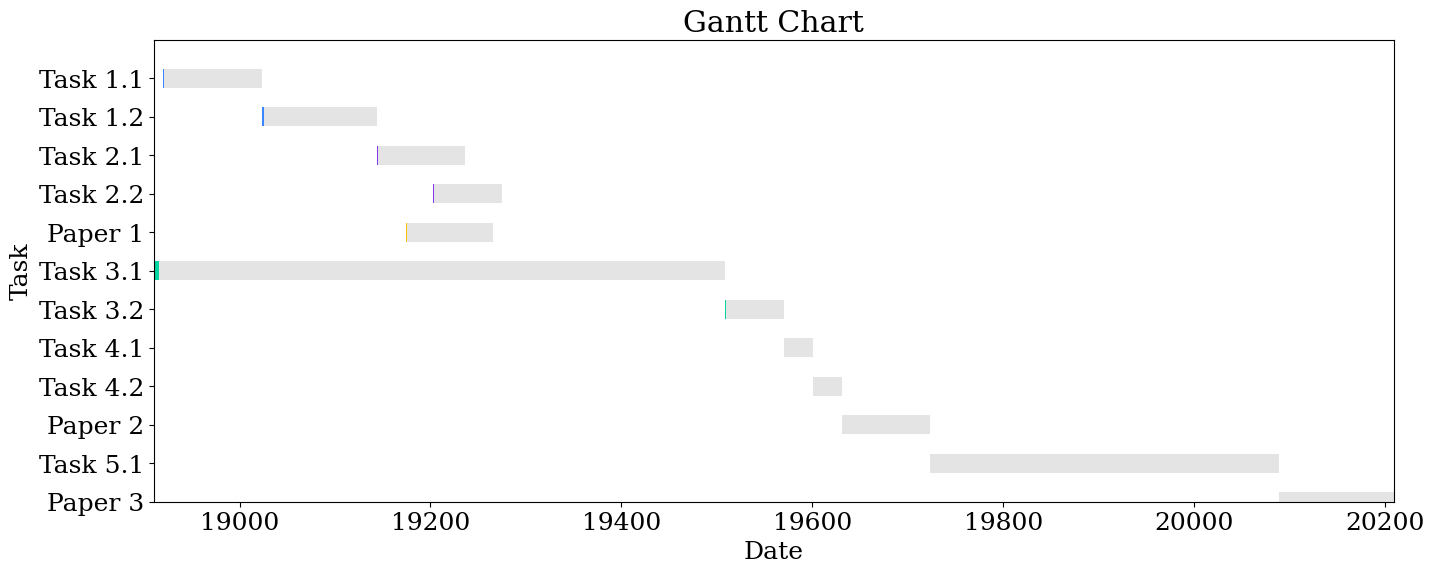

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

df = pd.read_excel('/content/PhD_Gantt_chart_data.xlsx')

# Set the time columns as datetime:
df['Start'] = pd.to_datetime(df['Start'],dayfirst=True)
df['End'] = pd.to_datetime(df['End'],dayfirst=True)

# Convert the date columns to a format that can be plotted on the x-axis
df['Start'] = mdates.date2num(df['Start'])
df['End'] = mdates.date2num(df['End'])

# create a column with the color for each kind of the task
def color(row):
    c_dict = {'Task 1.1':'#3a86ff', 'Task 1.2':'#3a86ff', 'Task 2.1':'#8338ec', 'Task 2.2':'#8338ec',
              'Paper 1':"#ffbe0b", 'Task 3.1':'#06d6a0','Task 3.2':'#06d6a0',"Task 4.1":'#06d6a0',"Task 4.2":'#06d6a0',
              'Paper 2':"#ffbe0b","Task 5.1":'#06d6a0',
              'Paper 3':"#ffbe0b"
              }
    return c_dict[row['Task']]
df['color'] = df.apply(color, axis=1)

# Create a figure and axis object
fig, ax = plt.subplots(1, figsize=(16,6))

# Set the x-axis limits
ax.set_xlim([df['Start'].min(), df['End'].max()])

# Set the y-axis limits
ax.set_ylim([0, len(df)])

# Set the y-axis labels
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['Task'])

# Plot the bars for each task
for i in range(len(df)):
    start = df['Start'][i]
    end = df['End'][i]
    color = df['color'][i]
    alpha = df['Completion'][i]
    ax.barh(i, end - start, left=start, height=0.5, color='lightgray', alpha=0.6)
    ax.barh(i, (end - start) * alpha / 100, left=start, height=0.5, color=color, alpha=1)

# Set the title and axis labels
ax.set_title('Gantt Chart')
ax.set_xlabel('Date')
ax.set_ylabel('Task')

# Save the chart as a PNG file
plt.savefig('chart.png')

plt.show()


In [ ]:
df

,Task,Name,Phase,Start,End,Completion,color
0,Paper 3,NaN,Ph.D.,20089.0,20209.0,0.0,#ffbe0b
1,Task 5.1,Develop a Comprehensive ML Project System usin...,Ph.D.,19723.0,20089.0,0.0,#06d6a0
2,Paper 2,NaN,Ph.D.,19631.0,19723.0,0.0,#ffbe0b
3,Task 4.2,Utilizing Models for Spatial Mapping and Anoma...,Ph.D.,19601.0,19631.0,0.0,#06d6a0
4,Task 4.1,Design image-based monitoring model based on h...,Ph.D.,19570.0,19601.0,0.0,#06d6a0
5,Task 3.2,Develop ML-based planning model based on LI-68...,Ph.D.,19509.0,19570.0,0.5,#06d6a0
6,Task 3.1,Leaves samples data acquisition,M.Sc.,18910.0,19509.0,1.0,#06d6a0
7,Paper 1,"co2 reduction, and energy-saving benefits of a...",M.Sc.,19174.0,19266.0,1.0,#ffbe0b
8,Task 2.2,CO2 experiments,M.Sc.,19203.0,19275.0,1.0,#8338ec
9,Task 2.1,Temperature and RH,M.Sc.,19144.0,19236.0,1.0,#8338ec
